# Forex_DNN Machine Learning Research & Validation Workbench

This notebook serves as a development laboratory for the complete ML workflow in the Forex_DNN framework.
It executes the end-to-end pipeline (from raw historical data loading to model training, evaluation, error analysis, and saving experiment outputs) on a small dataset (EURUSD M5) for fast development iterations.

Each section corresponds to a future production module.

## Section 1: Configuration

Allow easy configuration of parameters and display selected configuration before execution.

In [1]:
import os
import sys
import json
import time
import random
import logging
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add repo root to path to ensure proper imports
sys.path.append(os.path.abspath('..'))

# Set logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger("ResearchWorkbench")

# Set seeds for reproducibility
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)

# Configure hyperparameters
config = {
    "data_dir": "../HistoricalData",
    "symbol": "EURUSD",
    "timeframe": "M5",
    "max_candles": 10000,          # Sliced for fast execution in development workbench
    "window_size": 35,
    "model_type": "MarketStateClassifier", # Choose: "MarketStateClassifier" or "LevelBreakProbabilityModel"
    "random_seed": 42,
    "output_dir": "../output/research_experiments",
}

set_seeds(config["random_seed"])

print("=== WORKBENCH CONFIGURATION ===")
print(json.dumps(config, indent=4))

=== WORKBENCH CONFIGURATION ===
{
    "data_dir": "../HistoricalData",
    "symbol": "EURUSD",
    "timeframe": "M5",
    "max_candles": 10000,
    "window_size": 35,
    "model_type": "MarketStateClassifier",
    "random_seed": 42,
    "output_dir": "../output/research_experiments"
}


## Section 2: Load Historical Data

Load Parquet or CSV data. Perform checks for missing columns, duplicates, and NaN values, and abort if critical issues are found.

In [2]:
# Load historical symbol data
file_path = os.path.join(config['data_dir'], config['symbol'], f"{config['timeframe']}.parquet")
if not os.path.exists(file_path):
    file_path = os.path.join(config['data_dir'], f"{config['symbol']}_{config['timeframe']}.parquet")

# Fallbacks if running from inside notebooks folder vs root
if not os.path.exists(file_path):
    file_path = os.path.join('HistoricalData', config['symbol'], f"{config['timeframe']}.parquet")
    if not os.path.exists(file_path):
        file_path = os.path.join('HistoricalData', f"{config['symbol']}_{config['timeframe']}.parquet")

print(f'Loading data from {file_path}...')
df_raw = pd.read_parquet(file_path)

if config['max_candles'] and len(df_raw) > config['max_candles']:
    df_raw = df_raw.iloc[:config['max_candles']].copy()

# Ensure Datetime index
df_raw['Datetime'] = pd.to_datetime(df_raw['Datetime'])
df_raw = df_raw.sort_values('Datetime').reset_index(drop=True)

# Perform basic quality checks
total_candles = len(df_raw)
date_start = df_raw['Datetime'].min()
date_end = df_raw['Datetime'].max()
duplicate_count = df_raw['Datetime'].duplicated().sum()
missing_values_by_col = df_raw.isnull().sum()
total_missing_values = missing_values_by_col.sum()

time_deltas = df_raw['Datetime'].diff().dropna()
most_common_delta = time_deltas.mode()[0]
anomaly_deltas = time_deltas[time_deltas != most_common_delta]
missing_timestamps_detected = len(anomaly_deltas)

print('\n=== RAW DATA SUMMARY ===')
print(f'Total Candles: {total_candles}')
print(f'Date Range: {date_start} to {date_end}')
print(f'Duplicate Timestamps: {duplicate_count}')
print(f'Total Missing Values: {total_missing_values}')
print(f'Missing Values by Column:\n{missing_values_by_col}')
print(f'Standard Time Interval: {most_common_delta}')
print(f'Time gaps / missing candles: {missing_timestamps_detected}')

print('\nFirst 3 rows:')
print(df_raw.head(3))
print('\nLast 3 rows:')
print(df_raw.tail(3))

# Abort guard checks
if duplicate_count > 0.05 * len(df_raw):
    raise ValueError('Aborting: duplicate timestamps count exceeds 5% threshold.')
if total_missing_values > 0.1 * df_raw.size:
    raise ValueError('Aborting: missing cell values exceed 10% threshold.')

Loading data from ../HistoricalData\EURUSD\M5.parquet...

=== RAW DATA SUMMARY ===
Total Candles: 6433
Date Range: 2026-06-01 00:00:00+00:00 to 2026-07-01 00:00:00+00:00
Duplicate Timestamps: 0
Total Missing Values: 0
Missing Values by Column:
Datetime      0
Open          0
High          0
Low           0
Close         0
TickVolume    0
Spread        0
dtype: int64
Standard Time Interval: 0 days 00:05:00
Time gaps / missing candles: 4

First 3 rows:
                   Datetime     Open     High      Low    Close  TickVolume  \
0 2026-06-01 00:00:00+00:00  1.10033  1.10034  1.10032  1.10033         100   
1 2026-06-01 00:05:00+00:00  1.10032  1.10033  1.10032  1.10032         400   
2 2026-06-01 00:10:00+00:00  1.10032  1.10033  1.10031  1.10032         700   

   Spread  
0       2  
1       2  
2       2  

Last 3 rows:
                      Datetime     Open     High      Low    Close  \
6430 2026-06-30 23:50:00+00:00  1.10063  1.10064  1.10063  1.10063   
6431 2026-06-30 23:55:00+0

## Section 3: HistoricalDatasetBuilder

Run the modular technical indicator, market structure, and supply/demand engines pipeline.

In [3]:
from Market_Data_Pipeline.historical_dataset_builder import HistoricalDatasetBuilder

# Initialize builder with desired parameters
builder = HistoricalDatasetBuilder(
    input_dir=config['data_dir'],
    timeframe=config['timeframe'],
    window_size=config['window_size']
)

print('Executing HistoricalDatasetBuilder sequential transformation pipeline...')
start_time = time.time()
# Pipeline processes technical indicators, structural components, zones
df_enriched = builder.pipeline.execute(df_raw, config['symbol'], config['timeframe'])
elapsed = time.time() - start_time
print(f'Pipeline transformation execution completed in {elapsed:.4f} seconds.')

# Retrieve analytical stages
ms_stage = builder.pipeline.get_stage('MarketStructureEngine')
sd_stage = builder.pipeline.get_stage('SupplyDemandEngine')

# Build the shared MarketStructureGraph
from Market_Data_Pipeline.structure_graph import MarketStructureGraph
msg = MarketStructureGraph(
    symbol=config['symbol'],
    timeframe=config['timeframe'],
    swing_highs=[s for s in ms_stage.swings if s.level_type == 'SwingHigh'] if ms_stage else [],
    swing_lows=[s for s in ms_stage.swings if s.level_type == 'SwingLow'] if ms_stage else [],
    protected_high=ms_stage.protected_high if ms_stage else None,
    protected_low=ms_stage.protected_low if ms_stage else None,
    bos=list(ms_stage.bos_list) if ms_stage else [],
    choch=list(ms_stage.choch_list) if ms_stage else [],
    supply_zones=[z for z in sd_stage.zones if z.type == 'Supply'] if sd_stage else [],
    demand_zones=[z for z in sd_stage.zones if z.type == 'Demand'] if sd_stage else [],
    trend_direction='Bull' if df_enriched.iloc[-1].get('trend', 0) == 1 else ('Bear' if df_enriched.iloc[-1].get('trend', 0) == -1 else 'Neutral'),
    atr=float(df_enriched.iloc[-1].get('atr_14', 0.0001))
)

# Calculate window coverage
possible_windows = len(df_enriched) - config['window_size'] + 1
window_coverage_pct = (possible_windows / len(df_raw)) * 100

print('\n=== DETECTED ANOMALIES & STRUCTURE ELEMENT COUNTS ===')
print(f'Total Candles Enriched: {len(df_enriched)}')
print(f'Window Coverage:        {possible_windows} possible windows ({window_coverage_pct:.2f}% coverage)')
print(f'Swing Highs detected:   {len(msg.swing_highs)}')
print(f'Swing Lows detected:    {len(msg.swing_lows)}')
print(f'BOS instances:          {len(msg.bos)}')
print(f'CHOCH instances:        {len(msg.choch)}')
print(f'Supply Zones mapped:    {len(msg.supply_zones)}')
print(f'Demand Zones mapped:    {len(msg.demand_zones)}')
print('\nEnriched dataframe sample preview:')
print(df_enriched[['Open', 'High', 'Low', 'Close', 'ema_50', 'trend']].head(5))

2026-07-13 22:53:37,004 - Pipeline - INFO - Registered pipeline stage: IndicatorEngine
2026-07-13 22:53:37,004 - Pipeline - INFO - Registered pipeline stage: MarketStructureEngine
2026-07-13 22:53:37,005 - Pipeline - INFO - Registered pipeline stage: SupplyDemandEngine


Executing HistoricalDatasetBuilder sequential transformation pipeline...
Pipeline transformation execution completed in 40.4328 seconds.

=== DETECTED ANOMALIES & STRUCTURE ELEMENT COUNTS ===
Total Candles Enriched: 6433
Window Coverage:        6399 possible windows (99.47% coverage)
Swing Highs detected:   6579
Swing Lows detected:    6922
BOS instances:          366
CHOCH instances:        170
Supply Zones mapped:    0
Demand Zones mapped:    0

Enriched dataframe sample preview:
      Open     High      Low    Close    ema_50  trend
0  1.10033  1.10034  1.10032  1.10033  1.100330    0.0
1  1.10032  1.10033  1.10032  1.10032  1.100330    0.0
2  1.10032  1.10033  1.10031  1.10032  1.100329    0.0
3  1.10031  1.10032  1.10030  1.10031  1.100328    0.0
4  1.10031  1.10032  1.10030  1.10031  1.100328    0.0


## Section 4: LabelEngine

Apply deterministic, rule-based labeling. Support class distributions visualization, mapping ambiguous window drop percentages, and inspecting removal causes.

2026-07-13 22:54:17,466 - LabelEngine - INFO - LabelEngine processing EURUSD M5 with 6433 bars...


Running LabelEngine for MarketStateClassifier (TREND, RANGE, TRANSITION)...


2026-07-13 22:56:12,700 - LabelEngine - INFO - Dataset generation complete. Total windows: 6399. Labeled: 6200. Removed: 199.
2026-07-13 22:56:12,700 - LabelEngine - INFO -   Removed due to 'unlabeled_ambiguous': 199 samples.
C:\Users\MHossein\AppData\Local\Temp\ipykernel_20240\2697395014.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.index.astype(str), y=dist.values, palette='viridis')


Labeling process finished in 115.3505 seconds.
Total labeled dataset records generated: 6200

=== LABEL FREQUENCIES ===
Class 'TREND': 5111 (82.44%)
Class 'TRANSITION': 1077 (17.37%)
Class 'RANGE': 12 (0.19%)

Percentage of removed ambiguous windows: 3.11% (199 / 6399)
Reasons for ambiguous window removal:
{
    "unlabeled_ambiguous": 199
}


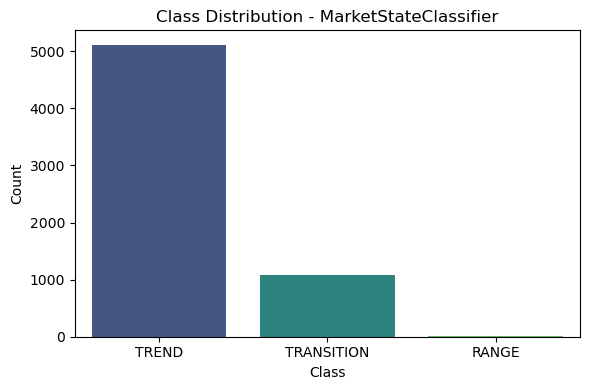

In [4]:
from ML.label_engine import LabelEngine
from ML.dataset_builder import DatasetBuilder
from ML.market_state_labeler import MarketStateLabeler

label_start = time.time()
if config['model_type'] == 'MarketStateClassifier':
    print('Running LabelEngine for MarketStateClassifier (TREND, RANGE, TRANSITION)...')
    label_engine = LabelEngine(
        window_size=config['window_size'],
        registry=builder.registry,
        labeler=MarketStateLabeler()
    )
    df_labeled = label_engine.generate_dataset(
        data_inputs=df_enriched,
        symbol=config['symbol'],
        timeframe=config['timeframe'],
        ms_engine=ms_stage,
        sd_engine=sd_stage
    )
    target_col = 'target'
else:
    print('Running DatasetBuilder for LevelBreakProbabilityModel (0 = REJECT, 1 = BREAK)...')
    db = DatasetBuilder(registry=builder.registry)
    df_labeled = db.build_level_break_dataset(df_enriched, msg)
    target_col = 'target'

print(f'Labeling process finished in {time.time() - label_start:.4f} seconds.')

# Standardize column naming: map timestamp to datetime if present
if 'timestamp' in df_labeled.columns and 'datetime' not in df_labeled.columns:
    df_labeled = df_labeled.rename(columns={'timestamp': 'datetime'})

print(f'Total labeled dataset records generated: {len(df_labeled)}')

if len(df_labeled) == 0:
    raise ValueError('Zero records labeled. Adjust parameters or raw candle span!')

dist = df_labeled[target_col].value_counts()
dist_pct = df_labeled[target_col].value_counts(normalize=True) * 100

print('\n=== LABEL FREQUENCIES ===')
for val, cnt in dist.items():
    print(f"Class '{val}': {cnt} ({dist_pct[val]:.2f}%)")

if config['model_type'] == 'MarketStateClassifier':
    tot = label_engine.total_windows_processed
    rem = label_engine.removed_samples_count
    print(f'\nPercentage of removed ambiguous windows: {rem / tot * 100:.2f}% ({rem} / {tot})')
    print('Reasons for ambiguous window removal:')
    print(json.dumps(label_engine.removal_reasons, indent=4))

plt.figure(figsize=(6, 4))
sns.barplot(x=dist.index.astype(str), y=dist.values, palette='viridis')
plt.title(f'Class Distribution - {config["model_type"]}')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Section 5: FeaturePipeline

Extract indicators and structural features based on the FeatureRegistry. Verify complete registry matching.

In [5]:
from ML.feature_registry import FeatureRegistry
from ML.feature_pipeline import FeaturePipeline

registry = FeatureRegistry(load_defaults=True)
pipeline = FeaturePipeline(registry)
enabled_features = [f.name for f in registry.list_enabled()]
print(f'Number of enabled features in the central registry: {len(enabled_features)}')

missing_features = [f for f in enabled_features if f not in df_labeled.columns]
if missing_features:
    print(f'WARNING: {len(missing_features)} features missing. Filling with defaults...')
    for f in missing_features:
        df_labeled[f] = registry.get(f).default_value
else:
    print('SUCCESS: All features registered in the FeatureRegistry exist in the dataset.')

# Categorize and print
categories = {}
for f in registry.list_enabled():
    categories[f.category] = categories.get(f.category, []) + [f.name]

print('\n=== FEATURE CATEGORIES ===')
for cat, feats in categories.items():
    print(f"Category '{cat}': {len(feats)} features. E.g.: {feats[:4]}")

Number of enabled features in the central registry: 50
SUCCESS: All features registered in the FeatureRegistry exist in the dataset.

=== FEATURE CATEGORIES ===
Category 'Trend': 11 features. E.g.: ['ema50_slope', 'ema600_slope', 'ema800_slope', 'ema_separation']
Category 'Momentum': 3 features. E.g.: ['candle_body', 'upper_wick', 'lower_wick']
Category 'Structure': 8 features. E.g.: ['bos_count_last_n', 'choch_count_last_n', 'time_since_last_bos', 'time_since_last_choch']
Category 'SupplyDemand': 10 features. E.g.: ['supply_distance', 'supply_width', 'supply_strength', 'supply_freshness']
Category 'PriceAction': 4 features. E.g.: ['candle_range', 'volume', 'spread', 'range_score']
Category 'Volatility': 6 features. E.g.: ['atr', 'atr_percentile', 'atr_ratio', 'realized_volatility']
Category 'Time': 2 features. E.g.: ['hour', 'weekday']
Category 'Session': 1 features. E.g.: ['session']
Category 'Position': 5 features. E.g.: ['distance_to_nearest_high', 'distance_to_nearest_low', 'dista

## Section 6: DatasetCleaner

Use DatasetCleaner to automatically clear NaNs, duplicates, and any constant-value columns.

In [6]:
from ML.data_cleaner import DataCleaner

cleaner = DataCleaner()
print(f'Dimensions before cleaning: {df_labeled.shape}')
df_cleaned = cleaner.clean(df_labeled, label_col=target_col)
print(f'Dimensions after cleaning:  {df_cleaned.shape}')
print(f'Removed {len(df_labeled) - len(df_cleaned)} rows during cleaning.')

Dimensions before cleaning: (6200, 75)


2026-07-13 22:56:13,054 - DataCleaner - INFO - Encoding categorical column 'session' to categorical codes.
2026-07-13 22:56:13,054 - DataCleaner - INFO - Encoding categorical column 'symbol' to categorical codes.
2026-07-13 22:56:13,054 - DataCleaner - INFO - Encoding categorical column 'timeframe' to categorical codes.
2026-07-13 22:56:13,054 - DataCleaner - INFO - Encoding categorical column 'datetime' to categorical codes.
2026-07-13 22:56:13,072 - DataCleaner - INFO - Encoding categorical column 'label_version' to categorical codes.
2026-07-13 22:56:13,074 - DataCleaner - INFO - Encoding categorical column 'engine_version' to categorical codes.
2026-07-13 22:56:13,078 - DataCleaner - INFO - Encoding categorical column 'meta_labeler_rule_fired' to categorical codes.
2026-07-13 22:56:13,081 - DataCleaner - INFO - Dataset cleaning completed. Rows: 6200 -> 6200


Dimensions after cleaning:  (6200, 75)
Removed 0 rows during cleaning.


## Section 7: Dataset Inspection

Generate heatmaps, feature distributions, and auto-flag high-correlation or low-variance anomalies.

=== SUSPICIOUS FEATURE ANALYSIS ===
  - supply_distance: Constant column (zero variance)
  - supply_width: Constant column (zero variance)
  - supply_strength: Constant column (zero variance)
  - supply_freshness: Constant column (zero variance)
  - supply_touch_count: Constant column (zero variance)
  - demand_distance: Constant column (zero variance)
  - demand_width: Constant column (zero variance)
  - demand_strength: Constant column (zero variance)
  - demand_freshness: Constant column (zero variance)
  - demand_touch_count: Constant column (zero variance)

Plotting feature correlations (subset of 12 features)...


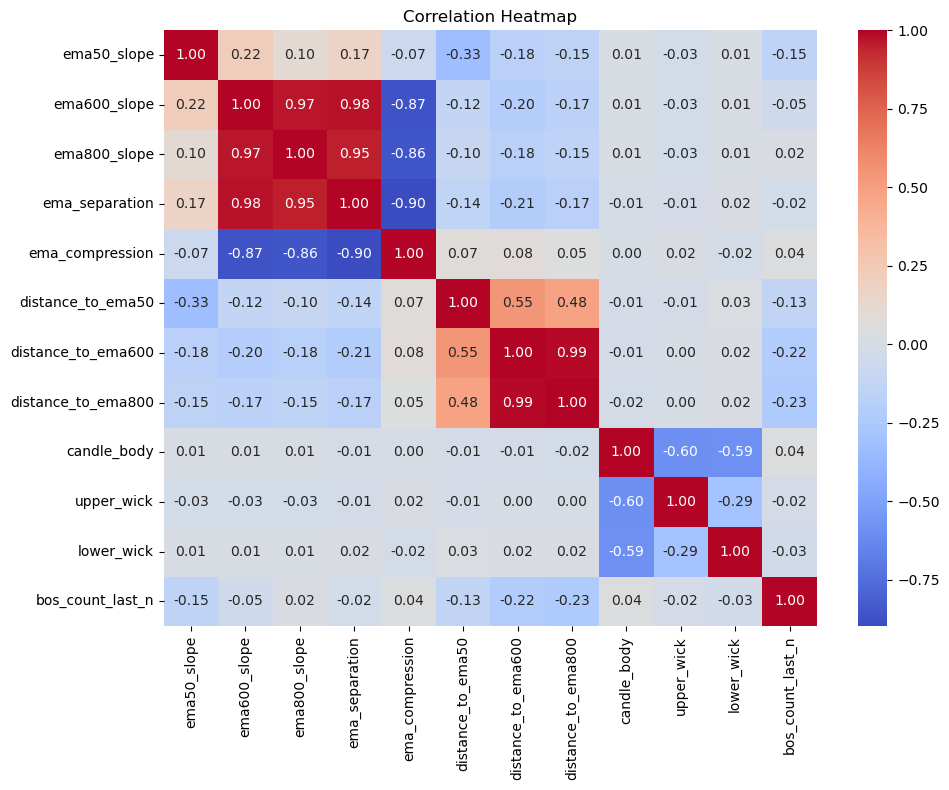

Plotting feature distribution metrics...


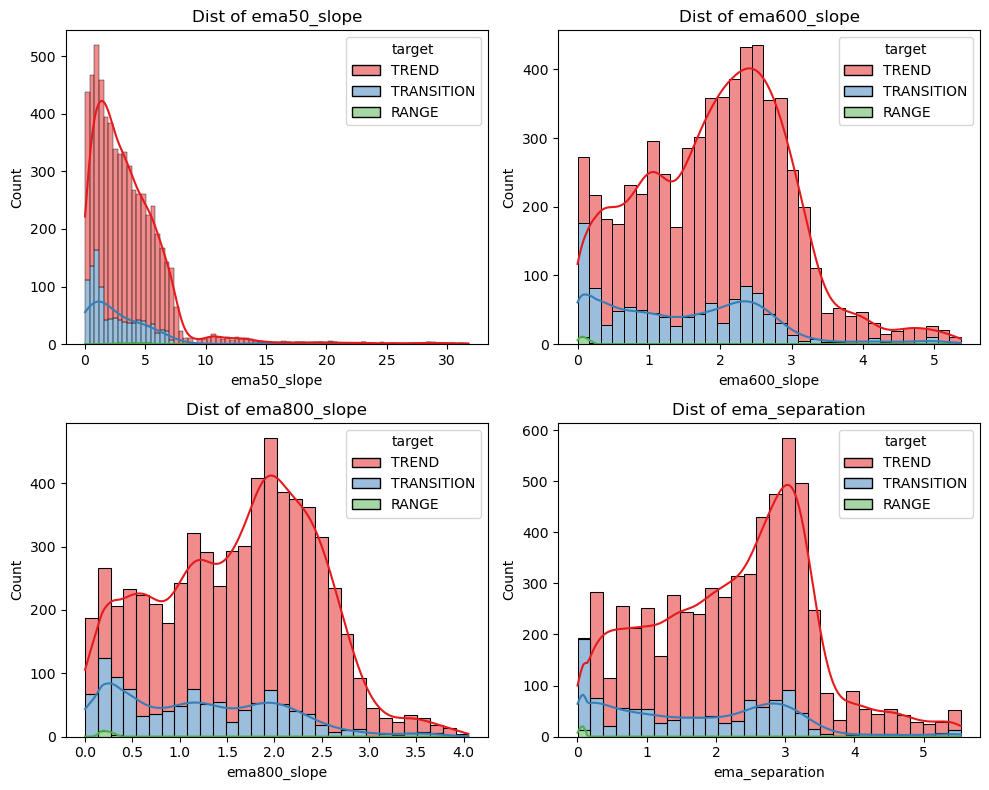

Plotting missing-value matrix (null heatmap)...


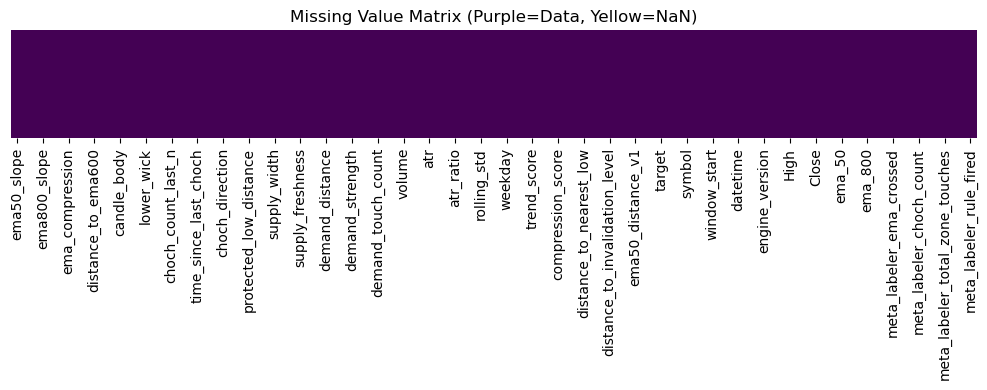

In [7]:
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns
exclude = ['target', 'confidence', 'window_start', 'window_end', 'Open', 'High', 'Low', 'Close', 'TickVolume', 'ema_50', 'ema_600', 'ema_800']
feature_cols = [c for c in numeric_cols if c not in exclude and not c.startswith('meta_')]

suspicious = []
for col in feature_cols:
    var = df_cleaned[col].var()
    if var == 0 or np.isnan(var) or df_cleaned[col].nunique() <= 1:
        suspicious.append((col, 'Constant column (zero variance)'))

corr = df_cleaned[feature_cols].corr().abs()
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        c1, c2 = feature_cols[i], feature_cols[j]
        if corr.loc[c1, c2] >= 0.99:
            suspicious.append((c1, f'Extremely high correlation with {c2} ({corr.loc[c1, c2]:.4f}) - potential redundancy.'))

print('=== SUSPICIOUS FEATURE ANALYSIS ===')
if suspicious:
    for col, r in suspicious[:10]:
        print(f'  - {col}: {r}')
else:
    print('No constant or colinear columns flagged.')

print('\nPlotting feature correlations (subset of 12 features)...')
subset_features = feature_cols[:12]
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned[subset_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Plotting feature distribution metrics...')
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx//2, idx%2]
    sns.histplot(data=df_cleaned, x=col, hue=target_col, ax=ax, kde=True, multiple='stack', palette='Set1')
    ax.set_title(f'Dist of {col}')
plt.tight_layout()
plt.show()

print('Plotting missing-value matrix (null heatmap)...')
plt.figure(figsize=(10, 4))
sns.heatmap(df_cleaned.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Matrix (Purple=Data, Yellow=NaN)')
plt.tight_layout()
plt.show()

## Section 8: Train / Validation / Test Split

Implement chronological splitting (no shuffling) to respect temporal causality.

In [8]:
df_cleaned = df_cleaned.sort_values('datetime').reset_index(drop=True)

train_split = 0.70
val_split = 0.15
test_split = 0.15

total_size = len(df_cleaned)
train_end = int(total_size * train_split)
val_end = int(total_size * (train_split + val_split))

df_train = df_cleaned.iloc[:train_end].copy()
df_val = df_cleaned.iloc[train_end:val_end].copy()
df_test = df_cleaned.iloc[val_end:].copy()

print('=== CHRONOLOGICAL DATA SPLIT ===')
print(f'Train:      {len(df_train)} samples ({train_split*100:.0f}%) | {df_train["datetime"].min()} to {df_train["datetime"].max()}')
print(f'Val:        {len(df_val)} samples ({val_split*100:.0f}%) | {df_val["datetime"].min()} to {df_val["datetime"].max()}')
print(f'Test:       {len(df_test)} samples ({test_split*100:.0f}%) | {df_test["datetime"].min()} to {df_test["datetime"].max()}')

assert df_train['datetime'].max() <= df_val['datetime'].min()
assert df_val['datetime'].max() <= df_test['datetime'].min()
print('SUCCESS: Strictly monotonic chronological split verified (0 overlap).')

=== CHRONOLOGICAL DATA SPLIT ===
Train:      4340 samples (70%) | 0 to 4339
Val:        930 samples (15%) | 4340 to 5269
Test:       930 samples (15%) | 5270 to 6199
SUCCESS: Strictly monotonic chronological split verified (0 overlap).


## Section 9: Feature Analysis

Identify feature importance using Random Forest, outlining the top 20 most predictive features.

Fitting RandomForest on Train set features...

=== TOP 20 INFLUENTIAL FEATURES ===
                        Feature  Importance
0           time_since_last_bos    0.189488
1         time_since_last_choch    0.106102
2                   ema50_slope    0.079099
3                ema_separation    0.075641
4               ema_compression    0.066652
5                  ema600_slope    0.039416
6                   trend_score    0.039035
7   distance_to_structure_break    0.037087
8                  ema800_slope    0.029905
9                      datetime    0.024259
10            ema50_distance_v2    0.023925
11            distance_to_ema50    0.022625
12            ema50_distance_v1    0.021885
13                  rolling_std    0.021596
14           distance_to_ema600    0.018988
15           distance_to_ema800    0.017066
16             bos_count_last_n    0.016431
17                    atr_ratio    0.015217
18         risk_reward_estimate    0.014625
19                  range_score    0.

C:\Users\MHossein\AppData\Local\Temp\ipykernel_20240\3104464881.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='mako')


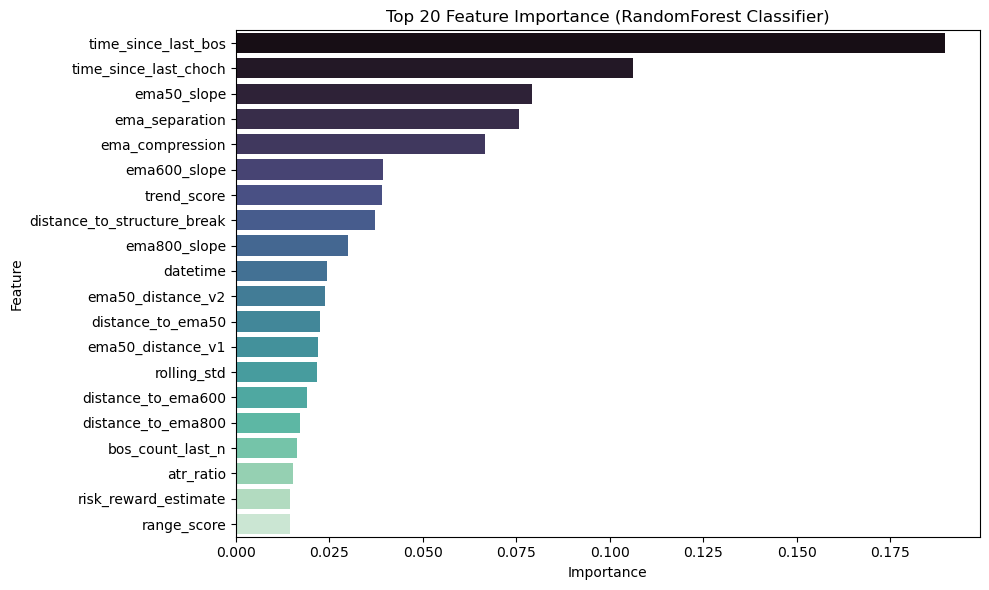

In [9]:
from sklearn.ensemble import RandomForestClassifier

classes = sorted(list(df_train[target_col].unique().astype(str).tolist()))
class_to_idx = {c: i for i, c in enumerate(classes)}

X_train_rf = df_train[feature_cols]
y_train_rf = df_train[target_col].astype(str).map(class_to_idx)

print('Fitting RandomForest on Train set features...')
rf = RandomForestClassifier(n_estimators=100, random_state=config['random_seed'], n_jobs=-1)
rf.fit(X_train_rf, y_train_rf)

importance = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\n=== TOP 20 INFLUENTIAL FEATURES ===')
print(importance_df.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature', palette='mako')
plt.title('Top 20 Feature Importance (RandomForest Classifier)')
plt.tight_layout()
plt.show()

## Section 10: Train Model

Instantiate and fit the wrapper model wrapper (`MarketStateClassifier` or `LevelBreakProbabilityModel`).

In [10]:
from ML.models.market_state_classifier import MarketStateClassifier
from ML.models.level_break_probability import LevelBreakProbabilityModel

X_train = df_train[feature_cols]
y_train = df_train[target_col].astype(str).map(class_to_idx).to_numpy()
X_val = df_val[feature_cols]
y_val = df_val[target_col].astype(str).map(class_to_idx).to_numpy()
X_test = df_test[feature_cols]
y_test = df_test[target_col].astype(str).map(class_to_idx).to_numpy()

print(f'Training production model: {config["model_type"]}...')
start_train = time.time()
if config['model_type'] == 'MarketStateClassifier':
    model = MarketStateClassifier(model_type='lightgbm', random_state=config['random_seed'])
    model.fit(X_train, y_train, feature_names=feature_cols)
else:
    model = LevelBreakProbabilityModel(model_type='lightgbm', random_state=config['random_seed'])
    model.fit(X_train, y_train, feature_names=feature_cols)
print(f'Training successfully finished in {time.time() - start_train:.4f} seconds.')

Training production model: MarketStateClassifier...


2026-07-13 22:56:20,753 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.


Training successfully finished in 1.8563 seconds.


## Section 11: Evaluate Model

Generate full metric evaluations, including Accuracy, F1-scores, Calibration curves, ROC, and PR curves.

c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\MHossein\anaconda3\envs\quant-env\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

=== PERFORMANCE RESULTS ===
Accuracy:  0.9452
Precision: 0.9398
Recall:    0.9452
F1 Score:  0.9418

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       RANGE       0.00      0.00      0.00         9
  TRANSITION       0.81      0.92      0.86       177
       TREND       0.98      0.96      0.97       744

    accuracy                           0.95       930
   macro avg       0.60      0.63      0.61       930
weighted avg       0.94      0.95      0.94       930

Confusion Matrix:
[[  0   9   0]
 [  0 163  14]
 [  0  28 716]]


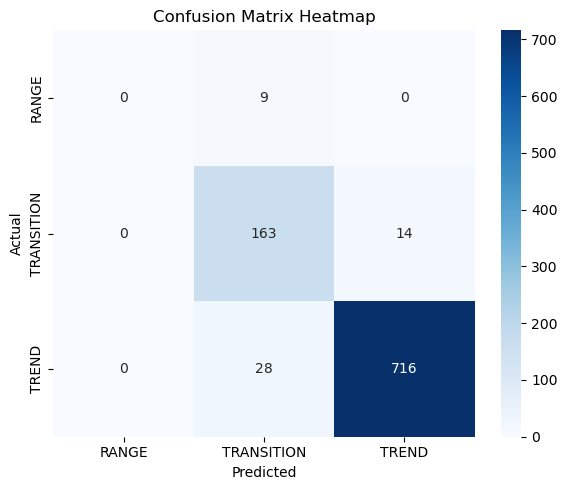

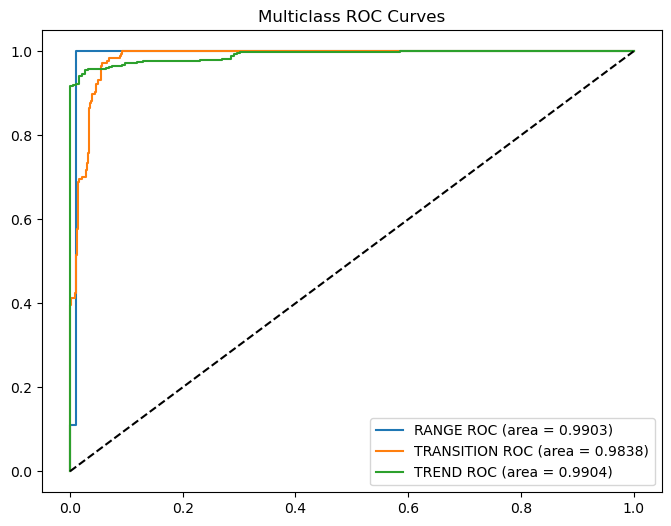

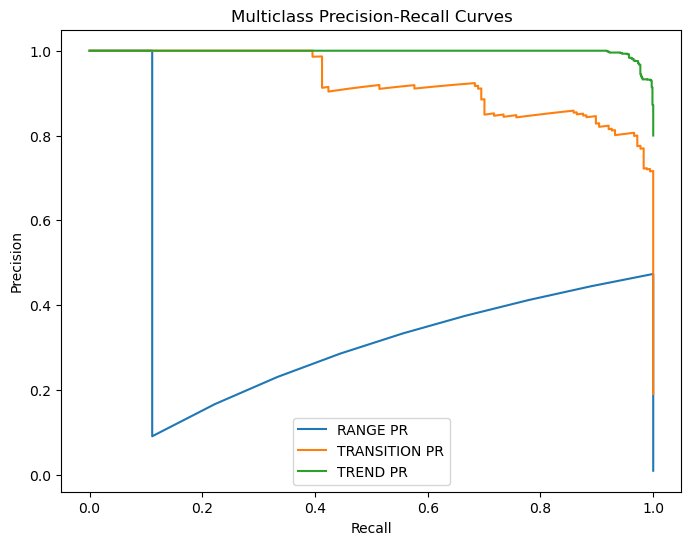

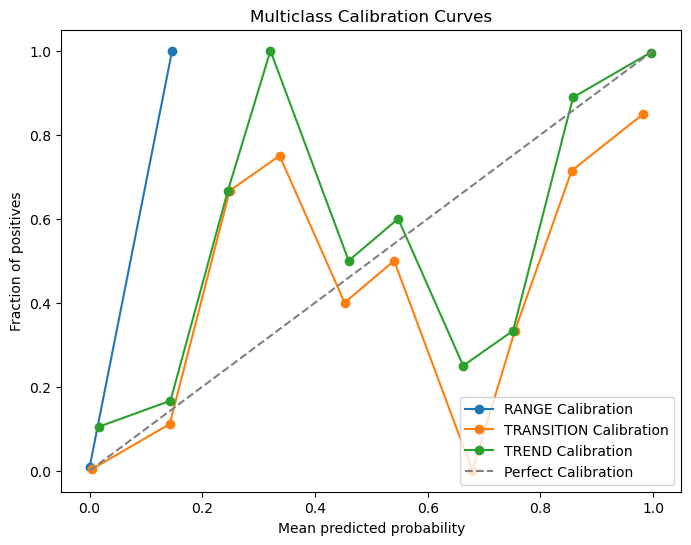

2026-07-13 22:56:21,889 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.
2026-07-13 22:56:22,004 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.


Generating Learning Curve plot...


2026-07-13 22:56:22,143 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.
2026-07-13 22:56:22,394 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.
2026-07-13 22:56:22,711 - BaseTradingModel - INFO - Fitted model of type 'lightgbm' successfully.


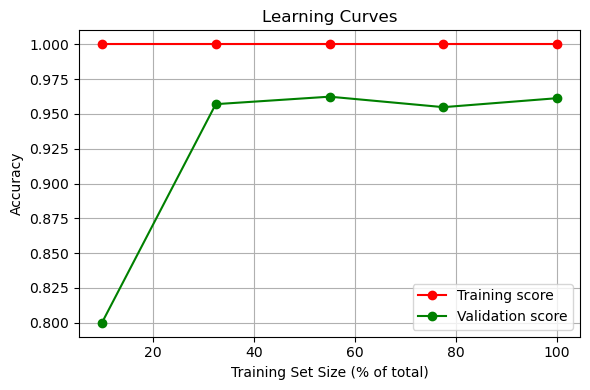

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.calibration import calibration_curve

y_pred = model.model.predict(X_test)
y_proba = model.model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('=== PERFORMANCE RESULTS ===')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1 Score:  {f1:.4f}')

print('\n=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

os.makedirs(os.path.join(config['output_dir'], 'plots'), exist_ok=True)
plots_path = os.path.join(config['output_dir'], 'plots')

# Heatmap confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'confusion_matrix.png'))
plt.show()

# curves generation
is_binary = len(classes) == 2
if is_binary:
    prob_1 = y_proba[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob_1)
    roc_auc = auc(fpr, tpr)
    
    precision, recall_val, _ = precision_recall_curve(y_test, prob_1)
    prob_true, prob_pred = calibration_curve(y_test, prob_1, n_bins=10)
    
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], 'k--')
    plt.title('Receiver Operating Characteristic')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend()
    plt.savefig(os.path.join(plots_path, 'roc_curve.png'))
    plt.show()
    
    plt.figure(figsize=(6, 4))
    plt.plot(recall_val, precision, color='blue', lw=2, label='Precision-Recall curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'precision_recall_curve.png'))
    plt.show()
    
    plt.figure(figsize=(6, 4))
    plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Calibration Curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(plots_path, 'calibration_curve.png'))
    plt.show()
else:
    # Multiclass ROC curves
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(classes):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} ROC (area = {roc_auc:.4f})')
    plt.plot([0,1],[0,1], 'k--')
    plt.title('Multiclass ROC Curves')
    plt.legend()
    plt.savefig(os.path.join(plots_path, 'multiclass_roc_curve.png'))
    plt.show()
    
    # Multiclass PR curves
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(classes):
        precision, recall_val, _ = precision_recall_curve((y_test == i).astype(int), y_proba[:, i])
        plt.plot(recall_val, precision, label=f'{name} PR')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Multiclass Precision-Recall Curves')
    plt.legend()
    plt.savefig(os.path.join(plots_path, 'multiclass_precision_recall_curve.png'))
    plt.show()
    
    # Multiclass Calibration curves
    plt.figure(figsize=(8, 6))
    for i, name in enumerate(classes):
        prob_true, prob_pred = calibration_curve((y_test == i).astype(int), y_proba[:, i], n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label=f'{name} Calibration')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Mean predicted probability')
    plt.ylabel('Fraction of positives')
    plt.title('Multiclass Calibration Curves')
    plt.legend()
    plt.savefig(os.path.join(plots_path, 'multiclass_calibration_curve.png'))
    plt.show()

# Learning curves calculation
print('Generating Learning Curve plot...')
train_sizes = np.linspace(0.1, 1.0, 5)
train_scores = []
val_scores = []
for size in train_sizes:
    num_samples = int(len(X_train) * size)
    if num_samples < 10: continue
    X_sub = X_train.iloc[:num_samples]
    y_sub = y_train[:num_samples]
    if config['model_type'] == 'MarketStateClassifier':
        sub_model = MarketStateClassifier(model_type='lightgbm', random_state=config['random_seed'])
    else:
        sub_model = LevelBreakProbabilityModel(model_type='lightgbm', random_state=config['random_seed'])
    sub_model.fit(X_sub, y_sub, feature_names=feature_cols)
    
    sub_train_pred = sub_model.model.predict(X_sub)
    sub_val_pred = sub_model.model.predict(X_val)
    
    train_scores.append(accuracy_score(y_sub, sub_train_pred))
    val_scores.append(accuracy_score(y_val, sub_val_pred))

plt.figure(figsize=(6, 4))
plt.plot(train_sizes[-len(train_scores):] * 100, train_scores, 'o-', color='r', label='Training score')
plt.plot(train_sizes[-len(val_scores):] * 100, val_scores, 'o-', color='g', label='Validation score')
plt.xlabel('Training Set Size (% of total)')
plt.ylabel('Accuracy')
plt.title('Learning Curves')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_path, 'learning_curve.png'))
plt.show()

## Section 12: Error Analysis & Random Sample Explorer

Analyze prediction failures, examine histograms of prediction confidence, and use a dedicated Random Sample Explorer to visual-validate historical context and overlays.

=== ERROR ANALYSIS SUMMARY ===
Class 'RANGE': False Positives: 0 | False Negatives: 9
Class 'TRANSITION': False Positives: 37 | False Negatives: 14
Class 'TREND': False Positives: 14 | False Negatives: 28


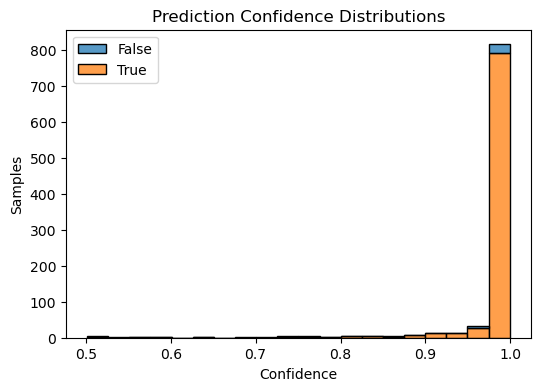


Worst confident error index in test set: 114
Actual Label: RANGE | Predicted: TRANSITION with 0.9950 confidence.


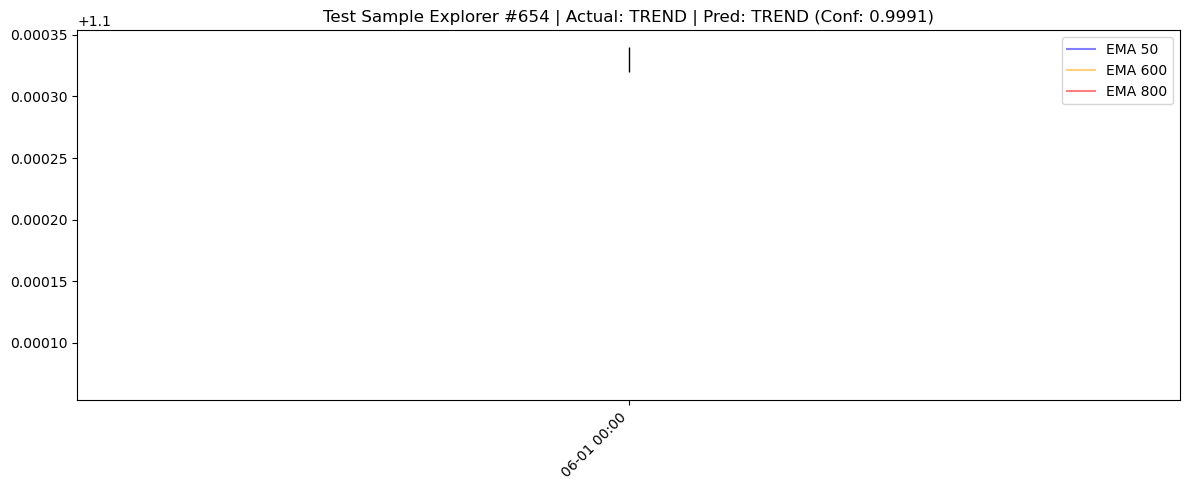

Sample Feature values:
  ema50_slope                   : 7.347418
  ema600_slope                  : 0.903137
  ema800_slope                  : 0.509954
  ema_separation                : 0.805820
  ema_compression               : 0.553765
  distance_to_ema50             : 4.632864
  distance_to_ema600            : 10.613291
  distance_to_ema800            : 8.732004


In [12]:
conf_predictions = np.max(y_proba, axis=1)
correct_mask = (y_pred == y_test)

# Calculate False Positives (FP) and False Negatives (FN) for the selected class
print('=== ERROR ANALYSIS SUMMARY ===')
if is_binary:
    fp = np.sum((y_pred == 1) & (y_test == 0))
    fn = np.sum((y_pred == 0) & (y_test == 1))
    print(f'False Positives: {fp} | False Negatives: {fn}')
else:
    # Multiclass error analysis
    for i, name in enumerate(classes):
        fp = np.sum((y_pred == i) & (y_test != i))
        fn = np.sum((y_pred != i) & (y_test == i))
        print(f"Class '{name}': False Positives: {fp} | False Negatives: {fn}")

plt.figure(figsize=(6, 4))
sns.histplot(x=conf_predictions, hue=correct_mask, bins=20, multiple='stack', palette='tab10')
plt.title('Prediction Confidence Distributions')
plt.xlabel('Confidence')
plt.ylabel('Samples')
plt.savefig(os.path.join(plots_path, 'confidence_histogram.png'))
plt.show()

incorrect = np.where(~correct_mask)[0]
if len(incorrect) > 0:
    worst_idx = incorrect[np.argmax(conf_predictions[incorrect])]
    print(f'\nWorst confident error index in test set: {worst_idx}')
    print(f'Actual Label: {classes[y_test[worst_idx]]} | Predicted: {classes[y_pred[worst_idx]]} with {conf_predictions[worst_idx]:.4f} confidence.')

def random_sample_explorer(test_idx=None):
    if test_idx is None:
        test_idx = random.choice(range(len(df_test)))
    
    sample_row = df_test.iloc[test_idx]
    dt = pd.to_datetime(sample_row['datetime'])
    
    # Safely convert to naive UTC datetime index and target for foolproof matching
    raw_dts_naive = pd.to_datetime(df_raw['Datetime']).dt.tz_localize(None)
    target_dt_naive = pd.to_datetime(dt).tz_localize(None)
    
    matches = df_raw[raw_dts_naive == target_dt_naive]
    if len(matches) == 0:
        # Fallback to closest matching time to avoid rounding anomalies
        raw_idx = (raw_dts_naive - target_dt_naive).abs().idxmin()
    else:
        raw_idx = matches.index[0]
    start_idx = max(0, raw_idx - config['window_size'] + 1)
    slice_candles = df_raw.iloc[start_idx:raw_idx + 1]

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    indices = np.arange(len(slice_candles))
    
    for i, (_, c) in enumerate(slice_candles.iterrows()):
        col = 'g' if c['Close'] >= c['Open'] else 'r'
        ax.vlines(i, c['Low'], c['High'], color='k', lw=1)
        ax.vlines(i, c['Open'], c['Close'], color=col, lw=6)
        
    ax.set_xticks(indices)
    ax.set_xticklabels([t.strftime('%m-%d %H:%M') for t in slice_candles['Datetime']], rotation=45, ha='right')
    
    # Overlay zones
    for z in msg.supply_zones:
        if z.created_idx <= raw_idx and (not z.broken or z.broken_idx >= start_idx):
            ax.axhspan(z.lower, z.upper, color='red', alpha=0.12, label='Supply Zone' if 'Supply Zone' not in ax.get_legend_handles_labels()[1] else '')
    for z in msg.demand_zones:
        if z.created_idx <= raw_idx and (not z.broken or z.broken_idx >= start_idx):
            ax.axhspan(z.lower, z.upper, color='green', alpha=0.12, label='Demand Zone' if 'Demand Zone' not in ax.get_legend_handles_labels()[1] else '')

    # Overlay BOS/CHOCH
    for b in msg.bos:
        if start_idx <= b.index <= raw_idx:
            ax.axhline(b.level, color='purple', linestyle='--', alpha=0.6, label='BOS' if 'BOS' not in ax.get_legend_handles_labels()[1] else '')
    for choch in msg.choch:
        if start_idx <= choch.index <= raw_idx:
            ax.axhline(choch.level, color='orange', linestyle='-.', alpha=0.6, label='CHOCH' if 'CHOCH' not in ax.get_legend_handles_labels()[1] else '')

    # Overlay EMA indicator lines
    if 'ema_50' in sample_row:
        ax.plot(indices, [sample_row['ema_50']] * len(indices), color='blue', linestyle='-', alpha=0.5, label='EMA 50')
    if 'ema_600' in sample_row:
        ax.plot(indices, [sample_row['ema_600']] * len(indices), color='orange', linestyle='-', alpha=0.5, label='EMA 600')
    if 'ema_800' in sample_row:
        ax.plot(indices, [sample_row['ema_800']] * len(indices), color='red', linestyle='-', alpha=0.5, label='EMA 800')

    p_label = classes[y_pred[test_idx]]
    t_label = classes[y_test[test_idx]]
    conf = conf_predictions[test_idx]
    
    ax.set_title(f'Test Sample Explorer #{test_idx} | Actual: {t_label} | Pred: {p_label} (Conf: {conf:.4f})')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    print('Sample Feature values:')
    for col in feature_cols[:8]:
        print(f'  {col:<30}: {sample_row[col]:.6f}')

random_sample_explorer()

## Section 13: Save Outputs

Save all model weights, configuration details, generated quality metrics, and performance plots under a timestamped experiment folder.

In [ ]:
import shutil

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
exp_dir = os.path.join(config['output_dir'], f'experiment_{timestamp}')
os.makedirs(exp_dir, exist_ok=True)

# Save model joblib
model_path = os.path.join(exp_dir, 'model.joblib')
model.save(model_path)

metrics = {
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'symbol': config['symbol'],
    'timeframe': config['timeframe'],
    'window_size': int(config['window_size']),
    'model_type': config['model_type']
}

with open(os.path.join(exp_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=4)
    
with open(os.path.join(exp_dir, 'config.json'), 'w') as f:
    json.dump(config, f, indent=4)
    
importance_df.to_json(os.path.join(exp_dir, 'feature_importance.json'), indent=4)

# Copy saved plots
shutil.copytree(plots_path, os.path.join(exp_dir, 'plots'), dirs_exist_ok=True)

# Save clean readable text summary and training log
summary_path = os.path.join(exp_dir, 'summary.txt')
with open(summary_path, 'w') as f:
    f.write('==================================================\n')
    f.write('      FOREX_DNN WORKBENCH EXPERIMENT SUMMARY      \n')
    f.write('==================================================\n')
    f.write(f'Timestamp:       {timestamp}\n')
    f.write(f'Model Type:      {config["model_type"]}\n')
    f.write(f'Symbol:          {config["symbol"]}\n')
    f.write(f'Timeframe:       {config["timeframe"]}\n')
    f.write(f'Window Size:     {config["window_size"]}\n')
    f.write(f'Seed:            {config["random_seed"]}\n')
    f.write(f'Accuracy:        {acc:.4f}\n')
    f.write(f'Precision:       {prec:.4f}\n')
    f.write(f'Recall:          {rec:.4f}\n')
    f.write(f'F1-Score:        {f1:.4f}\n')
    f.write('--------------------------------------------------\n')
    f.write(f'Total Cleaned Samples: {total_size}\n')
    f.write(f'Train Set Size:        {len(df_train)}\n')
    f.write(f'Validation Set Size:   {len(df_val)}\n')
    f.write(f'Test Set Size:         {len(df_test)}\n')
    f.write('==================================================\n')
print(f'SUCCESS: Complete workbench experiment outputs saved to: {exp_dir}')